# 04 — Boosting Model Training and Selection

This notebook compares XGBoost, LightGBM and CatBoost on identical leakage-safe folds. MLflow records the dataset lineage, nested model runs, parameters, fold and iteration metrics, OOF predictions, figures, system metrics, candidate model signature and reproducible environment.

## Evaluation protocol

1. Read `train_features.csv`; the reserved test set remains closed.
2. Use only application-time baseline features.
3. Compare all models with the same stratified folds and out-of-fold predictions.
4. Rank models with the configured selection metric.
5. Refit only the winner on all development rows.
6. Save the result for the independent diagnostics in notebook 05.

Threshold tuning, calibration, SHAP, lift, cumulative gains and final test evaluation intentionally belong to notebook 05.

In [1]:
from IPython.display import display

from bnpl_credit_risk.pipelines.boosting_benchmark_pipeline import (
    BoostingBenchmarkPipeline,
)
from bnpl_credit_risk.settings import get_settings, load_config
from bnpl_credit_risk.tracking import launch_mlflow_ui
from bnpl_credit_risk.visualization.boosting import (
    BoostingBenchmarkVisualizer,
)

settings = get_settings()
config = load_config()
benchmark_pipeline = BoostingBenchmarkPipeline(
    settings=settings,
    config=config,
)
benchmark_visualizer = BoostingBenchmarkVisualizer(
    size=config.model.benchmark.visualization.size,
)

## MLflow central

This cell starts the shared MLflow 3.14 UI only when it is not already running. The returned card links directly to the `bnpl_credit_risk` experiment stored under `/Users/surelmanda/.mlflow`.

In [2]:
mlflow_ui = launch_mlflow_ui(config)
mlflow_ui

MLflowUIHandle(url='http://127.0.0.1:5000', experiment_url='http://127.0.0.1:5000/#/experiments/8', experiment_name='bnpl_credit_risk', mlflow_version='3.14.0', process=<Popen: returncode: None args: ['/Users/surelmanda/3-Mlops-Databricks-Projec...>)

## 1. Load the development dataset

In [3]:
development_df = benchmark_pipeline.load_development()
benchmark_dataset = benchmark_pipeline.prepare(development_df)

print(f"Development shape: {development_df.shape}")
print(f"Numeric features: {benchmark_dataset.numeric_features}")
print(f"Categorical features: {benchmark_dataset.categorical_features}")
print(
    "Engineered features excluded from baseline: "
    f"{benchmark_dataset.excluded_engineered_features}"
)
display(
    benchmark_dataset.y.value_counts(normalize=True)
    .sort_index()
    .rename("Target share")
    .to_frame()
)

2026-08-28 13:27:30.922 | INFO     | bnpl_credit_risk.data.loaders:load_raw:37 - Loaded raw dataset path=/Users/surelmanda/3-Mlops-Databricks-Projects/BNPL-Credit-Risk/data/processed/train_features.csv rows=9310 columns=22


Development shape: (9310, 22)
Numeric features: ['age', 'monthly_income', 'credit_score', 'purchase_amount', 'bnpl_installments', 'app_usage_frequency', 'debt_to_income_ratio']
Categorical features: ['employment_type', 'product_category', 'location']
Engineered features excluded from baseline: ['affordability_band', 'age_group', 'credit_score_band', 'income_after_installment', 'installment_amount', 'installment_burden_ratio', 'installment_term', 'transaction_month_cos', 'transaction_month_sin']


,Target share
default_flag,
0,0.609452
1,0.390548


## 2. Train the three boosting candidates

The class below owns category isolation, early stopping, fold metrics, out-of-fold predictions and final refit. The notebook only starts the experiment.

In [4]:
benchmark_result = benchmark_pipeline.run(development_df)

2026/08/28 13:27:31 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/08/28 13:27:31 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
/Users/surelmanda/3-Mlops-Databricks-Projects/BNPL-Credit-Risk/.venv/lib/python3.11/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/Users/surelmanda/3-Mlops-Databricks-Projects/BNPL-Credit-Risk/.venv/lib/python3.11/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema en

## 3. Inspect each model consistently


XGBoost


,ROC-AUC,PR-AUC,Precision,Recall,F1 score,MCC,Brier score,Log loss
Fold,,,,,,,,
1,0.6978,0.5362,0.5283,0.3466,0.4186,0.1658,0.2031,0.5806
2,0.7061,0.5529,0.5673,0.3535,0.4356,0.2056,0.2042,0.5869
3,0.6921,0.5371,0.5456,0.4195,0.4743,0.2083,0.2061,0.5894
4,0.7033,0.5583,0.5582,0.3824,0.4539,0.2078,0.2029,0.5815
5,0.7208,0.5762,0.5781,0.4423,0.5012,0.2505,0.1978,0.5671


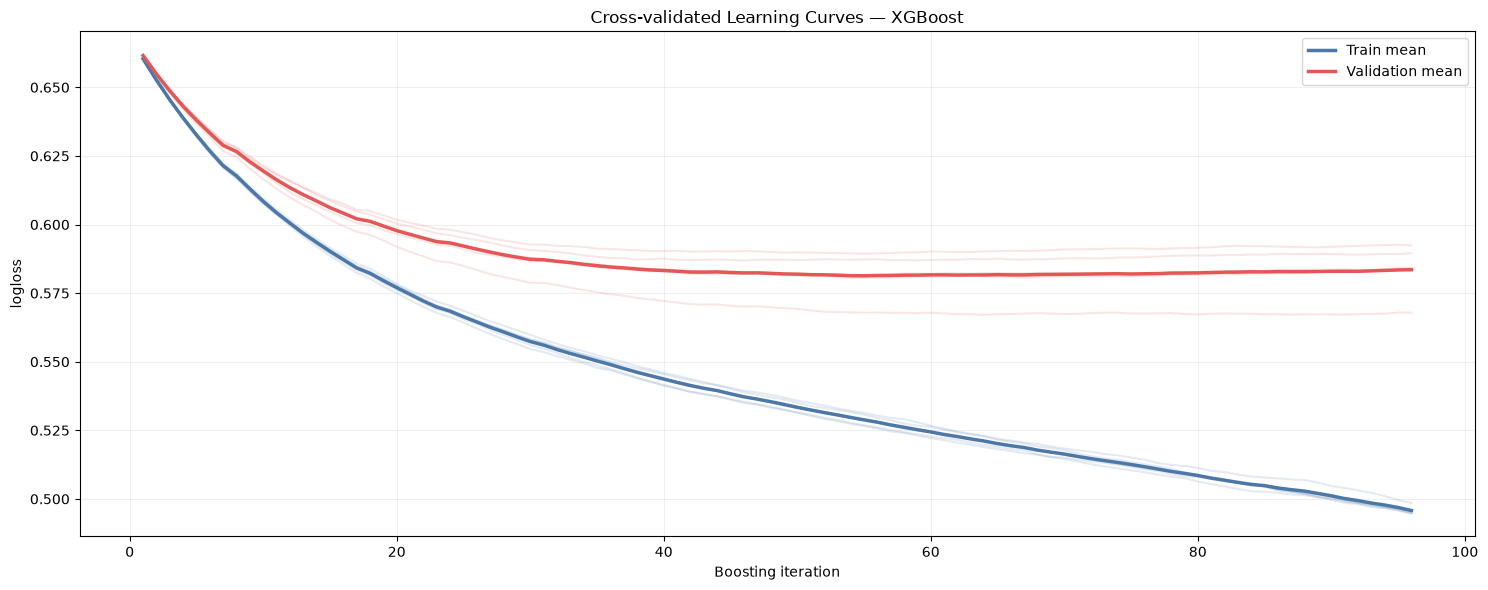

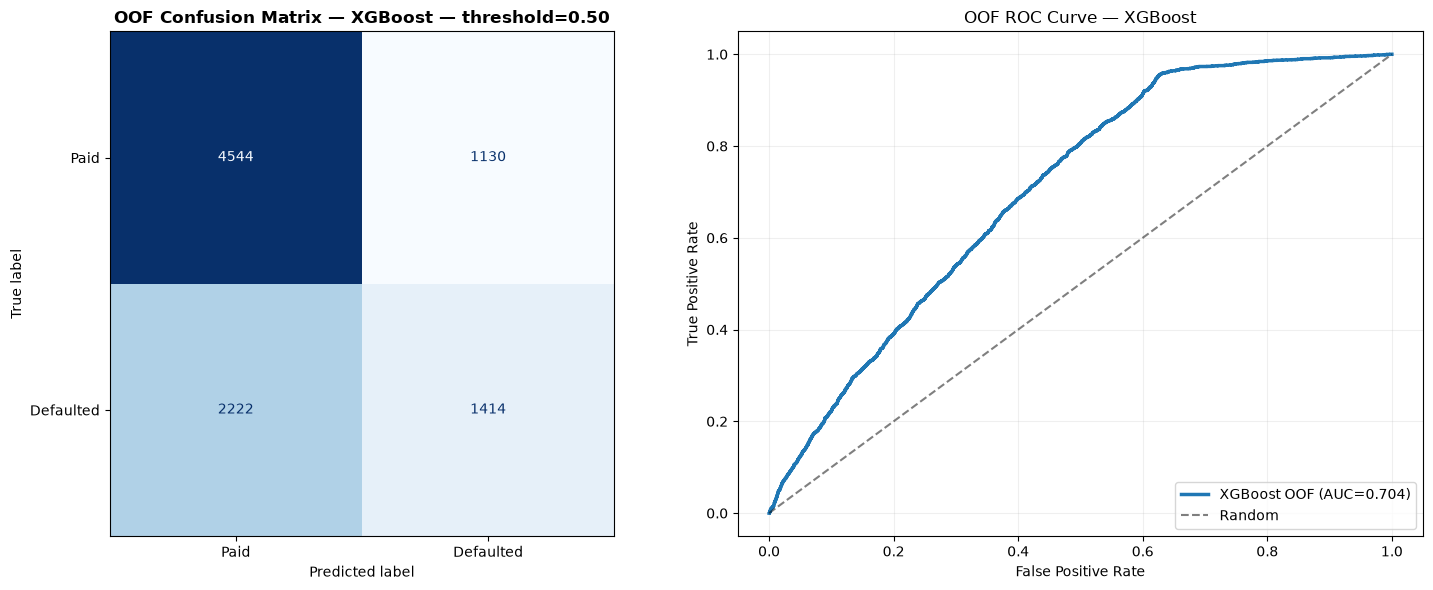

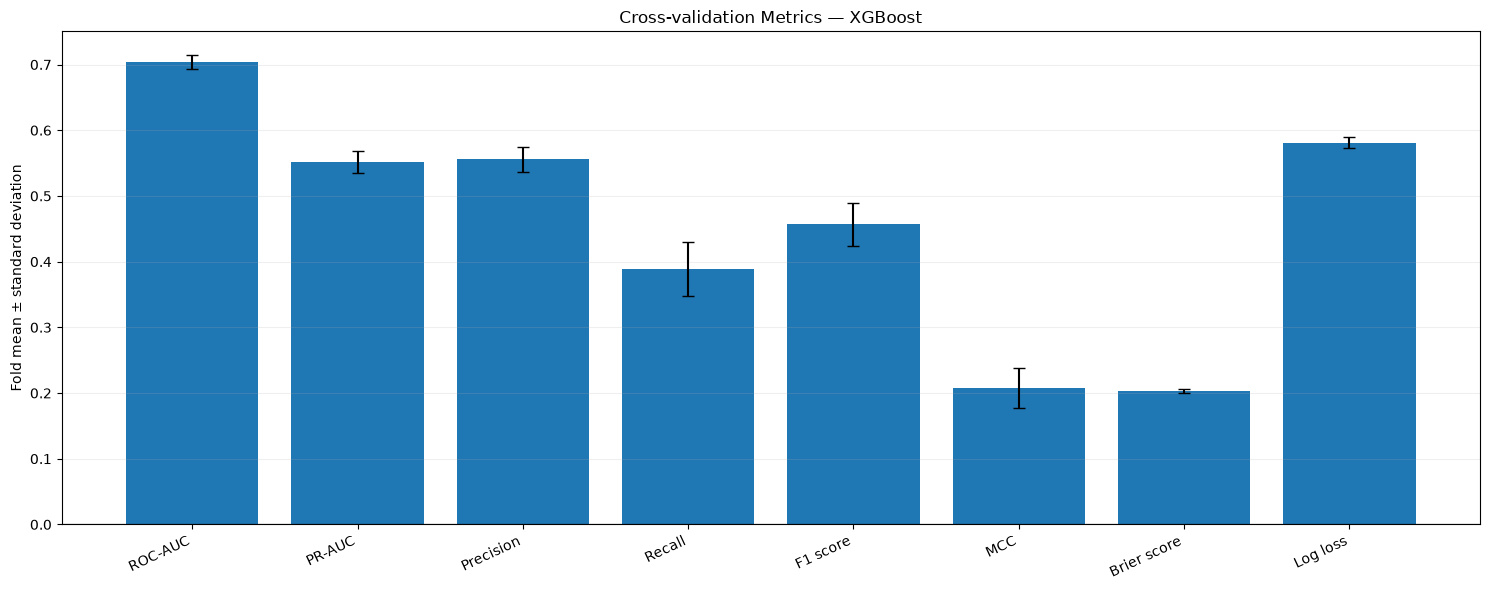


LightGBM


,ROC-AUC,PR-AUC,Precision,Recall,F1 score,MCC,Brier score,Log loss
Fold,,,,,,,,
1,0.6935,0.5323,0.5323,0.3631,0.4317,0.1752,0.2039,0.5822
2,0.6973,0.5534,0.5467,0.4264,0.4791,0.2120,0.2047,0.5867
3,0.6999,0.5532,0.5520,0.4525,0.4974,0.2272,0.2054,0.5887
4,0.6960,0.5468,0.5351,0.4085,0.4633,0.1933,0.2040,0.5836
5,0.7226,0.5753,0.5709,0.4313,0.4914,0.2387,0.1977,0.5663


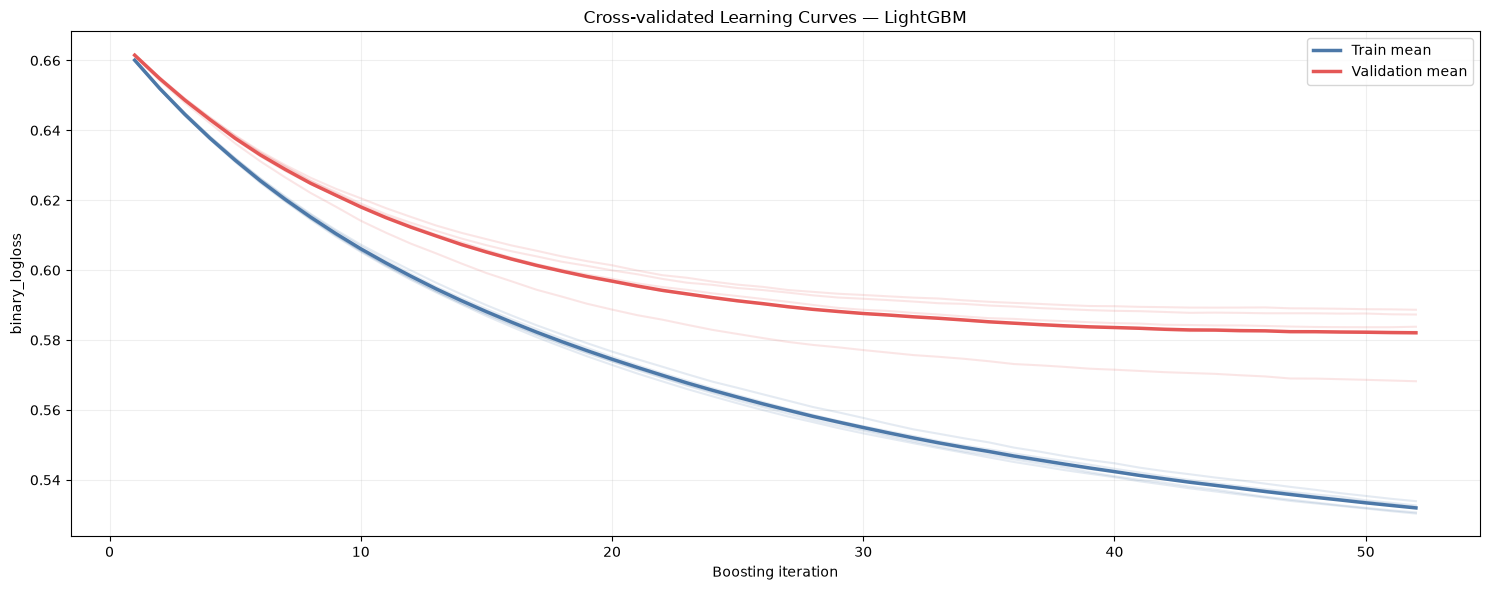

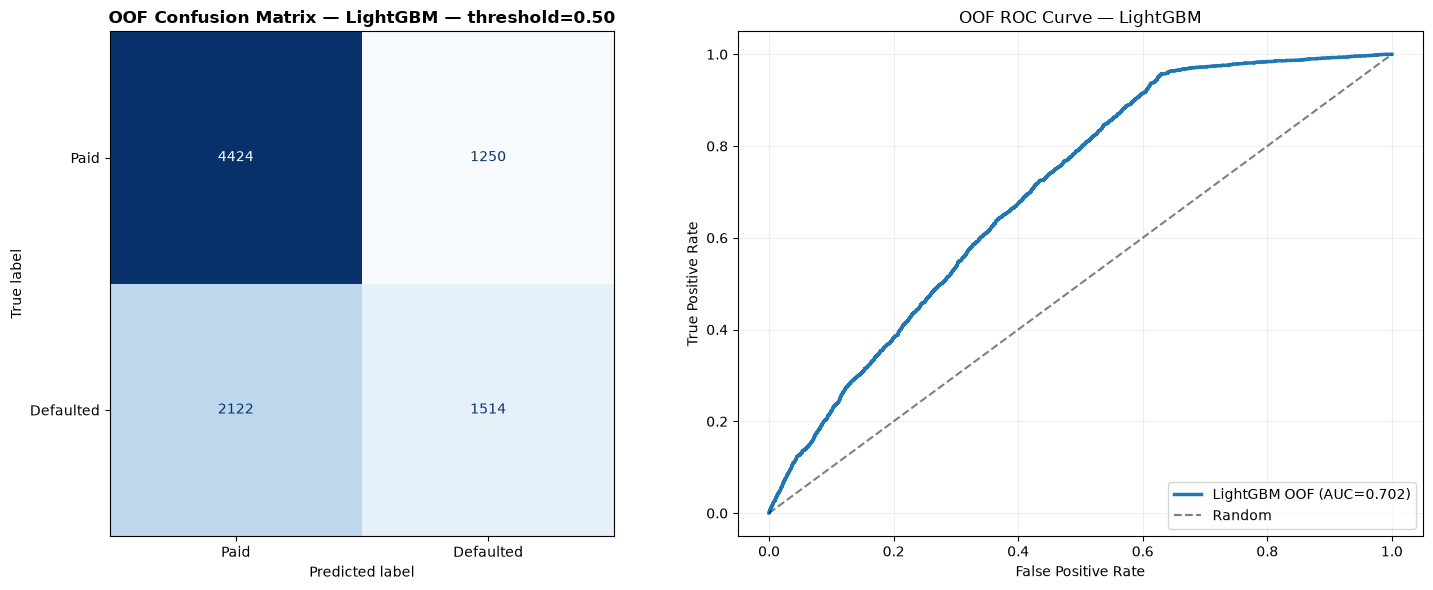

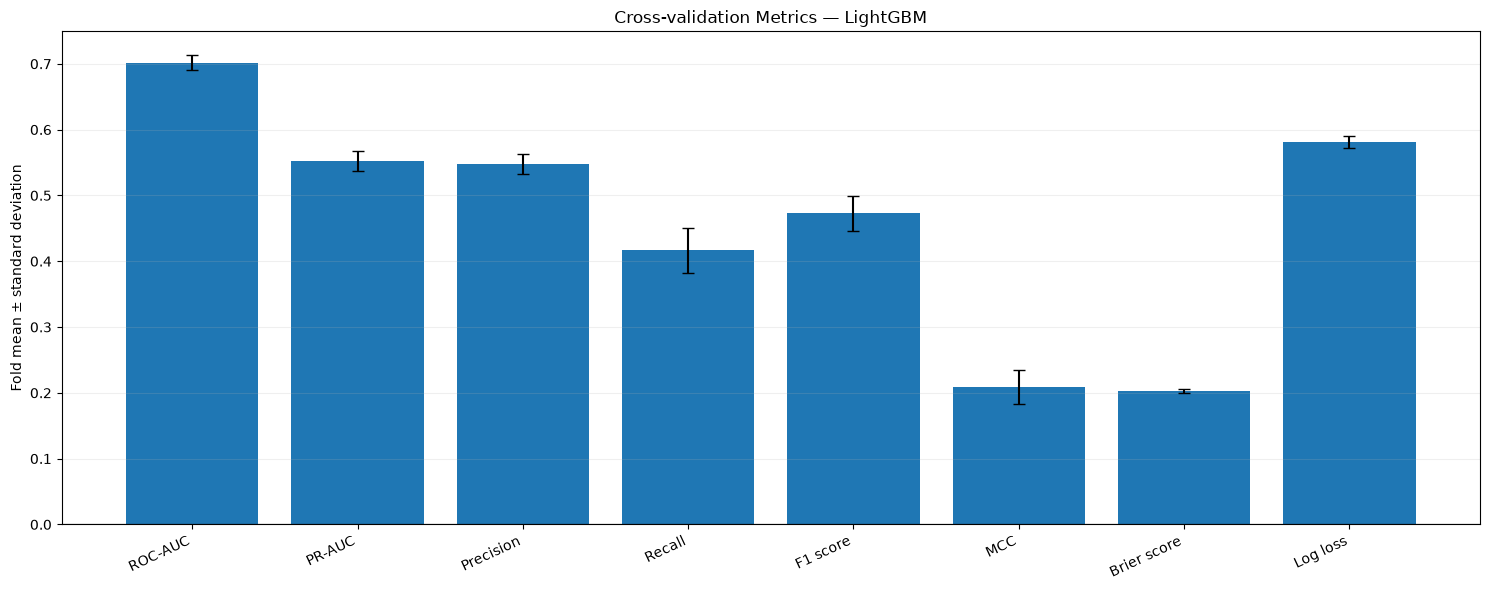


CatBoost


,ROC-AUC,PR-AUC,Precision,Recall,F1 score,MCC,Brier score,Log loss
Fold,,,,,,,,
1,0.7044,0.5622,0.5495,0.3741,0.4452,0.1962,0.2009,0.5764
2,0.7008,0.5467,0.5529,0.4168,0.4753,0.2151,0.2042,0.5862
3,0.7063,0.5600,0.5563,0.4691,0.5090,0.2382,0.2044,0.5863
4,0.7018,0.5558,0.5532,0.4223,0.4789,0.2173,0.2030,0.5814
5,0.7204,0.5776,0.5701,0.4299,0.4902,0.2374,0.1977,0.5677


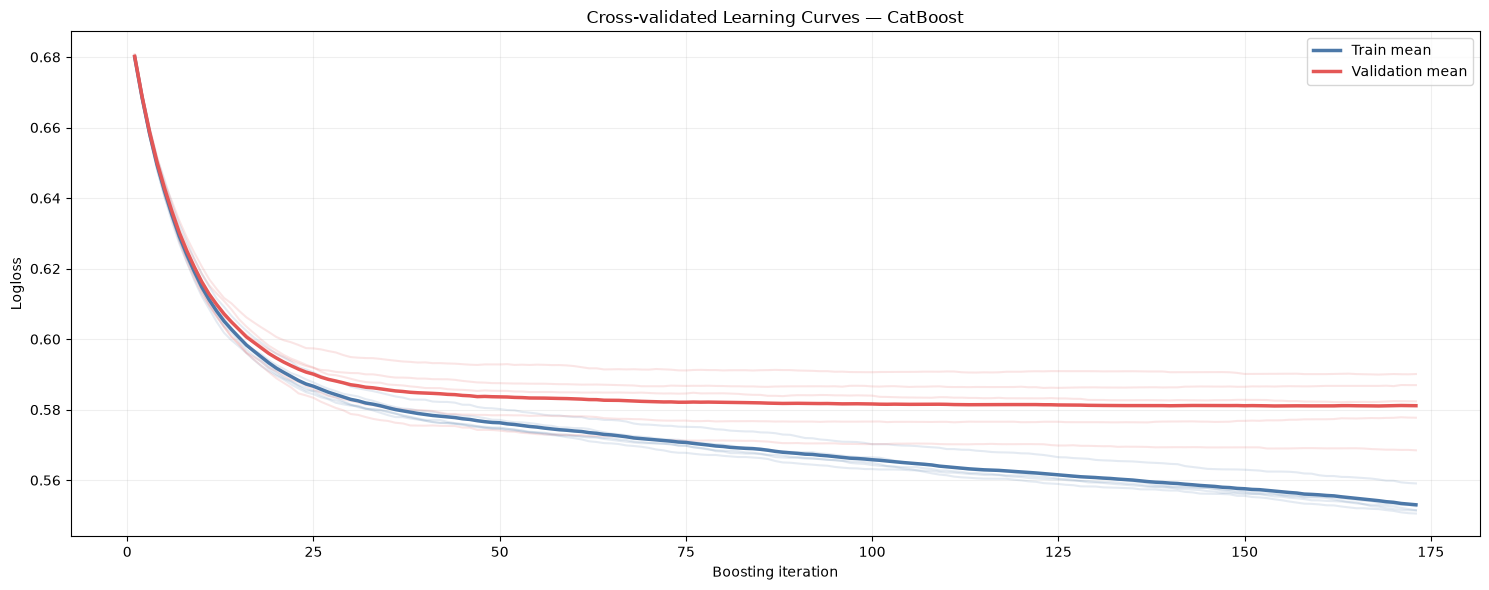

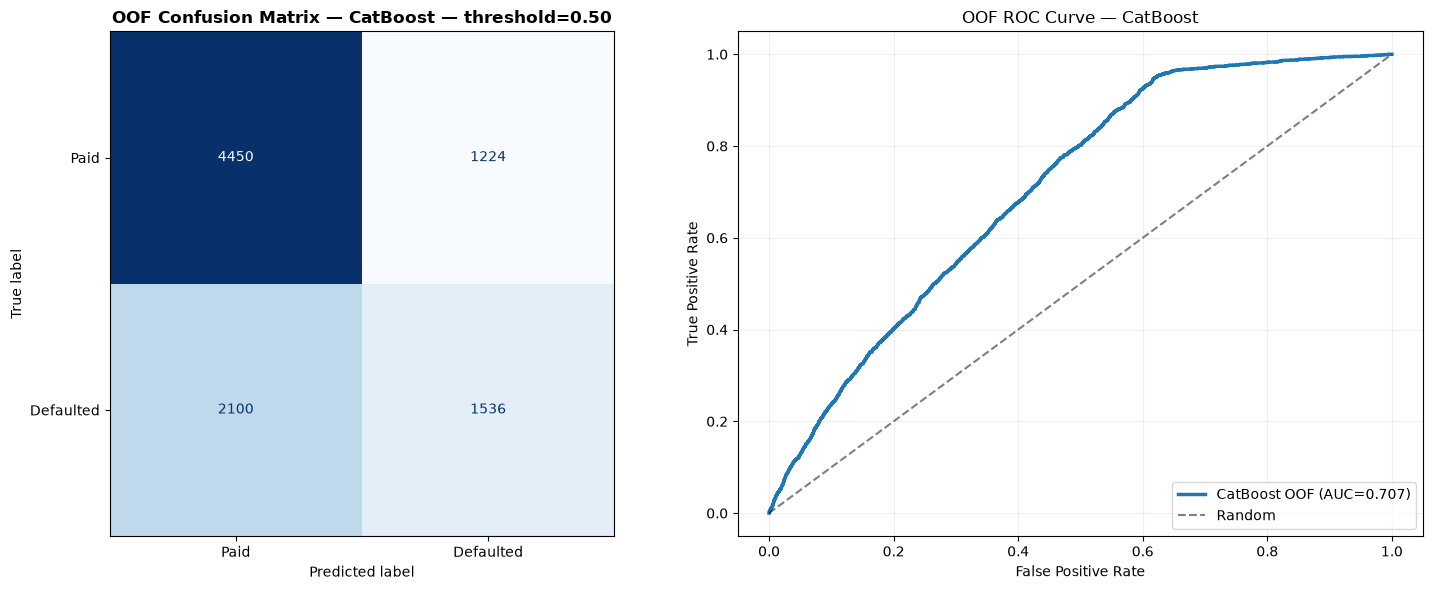

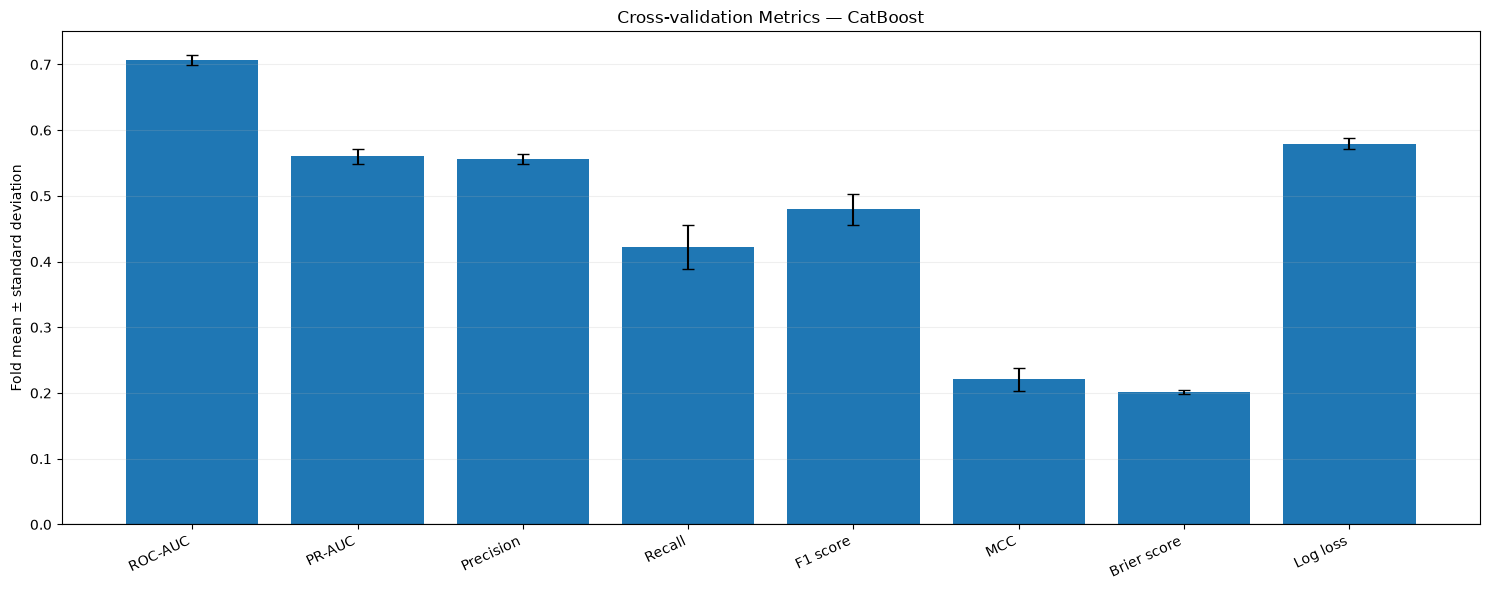

In [5]:
for model_name in config.model.benchmark.models:
    model_result = benchmark_result.models[model_name]
    print(f"\n{model_name}")
    display(model_result.fold_metrics.round(4))
    display(benchmark_visualizer.learning_curves(model_result))
    display(
        benchmark_visualizer.oof_performance(
            benchmark_dataset.y,
            model_result,
            threshold=config.model.benchmark.comparison_threshold,
        )
    )
    display(benchmark_visualizer.metric_summary(model_result))

## 4. Compare models and recover the winner

This selection concerns ranking quality only. The business decision threshold is not selected here.

,ROC-AUC mean,ROC-AUC std,PR-AUC mean,PR-AUC std,Precision mean,Precision std,Recall mean,Recall std,F1 score mean,F1 score std,MCC mean,MCC std,Brier score mean,Brier score std,Log loss mean,Log loss std,Median best iteration
Model,,,,,,,,,,,,,,,,,
CatBoost,0.7067,0.0079,0.5605,0.0113,0.5564,0.0080,0.4224,0.0339,0.4797,0.0233,0.2208,0.0175,0.2020,0.0028,0.5796,0.0078,222
XGBoost,0.7040,0.0108,0.5521,0.0166,0.5555,0.0193,0.3889,0.0415,0.4567,0.0324,0.2076,0.0300,0.2028,0.0031,0.5811,0.0087,55
LightGBM,0.7019,0.0118,0.5522,0.0155,0.5474,0.0154,0.4164,0.0336,0.4726,0.0263,0.2093,0.0256,0.2031,0.0031,0.5815,0.0089,61


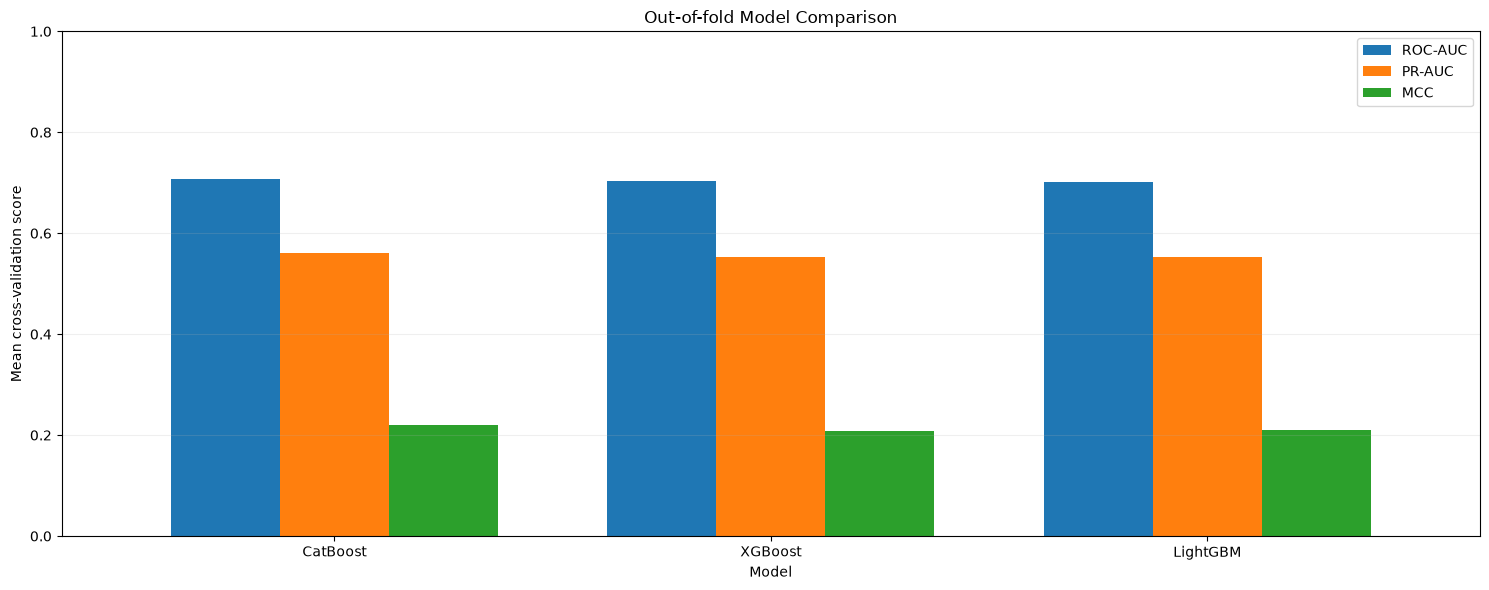

Selection metric: ROC-AUC
Selected model: CatBoost
Final boosting iterations: 222


In [6]:
display(benchmark_result.comparison.round(4))
display(benchmark_visualizer.comparison(benchmark_result))

print(f"Selection metric: {config.model.benchmark.selection_metric}")
print(f"Selected model: {benchmark_result.best_model_name}")
print(
    "Final boosting iterations: "
    f"{benchmark_result.best_result.median_best_iteration}"
)

## 5. Save the development benchmark

The local hand-off contains the winner required by notebook 05. Its complete experiment lineage is also attached to the active central MLflow run.

In [7]:
benchmark_artifact_dir = benchmark_pipeline.save(benchmark_result)
print(f"Saved benchmark: {benchmark_artifact_dir}")
print(f"MLflow run ID: {benchmark_pipeline.last_mlflow_run_id}")
print(f"MLflow experiment: {config.training.mlflow.experiment_name}")
print("Next step: notebooks/05_model_evaluation.ipynb")

Saved benchmark: /Users/surelmanda/3-Mlops-Databricks-Projects/BNPL-Credit-Risk/artifacts/benchmarks/2026-08-28_132813
MLflow run ID: 4dbf16220a894d32b2001a322f0ed140
MLflow experiment: bnpl_credit_risk
Next step: notebooks/05_model_evaluation.ipynb
